# DAY 7

In [34]:
import math
import scipy.stats as stats
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statistics


# set style for plots
plt.style.use('seaborn_v0_8_white' if 'seaborn_v0_8_white' in plt.style.available else 'default')
plt.rcParams["figure.dpi"] = 100 # set the dpi
# seed 
np.random.seed(42)

# 1. Ragne (Spread form Minimum to Maximum)

Plain Python calculation: 12°C
Numpy (np.max - np.min): 12°C
Numpy (np.ptp): 12°C


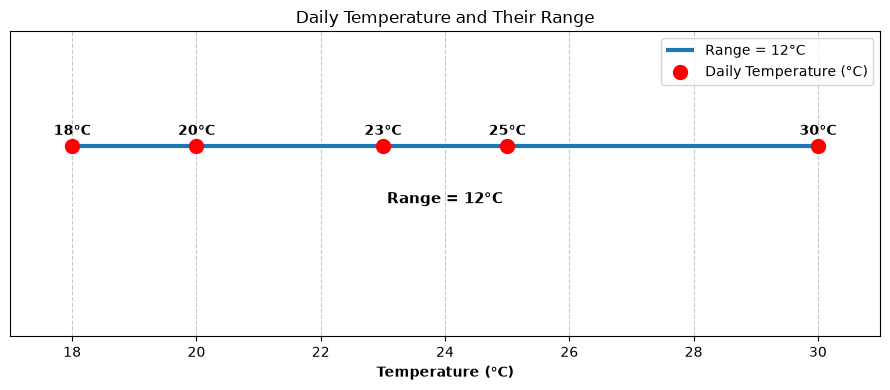

In [35]:
import numpy as np
import matplotlib.pyplot as plt

temperature = [18, 20, 23, 25, 30]

# Minimum and maximum values
min_val = min(temperature)
max_val = max(temperature)

# Range calculations
range_python = max(temperature) - min(temperature)

range_np_minmax = np.max(temperature) - np.min(temperature)

range_np_ptp = np.ptp(temperature)

print(f"Plain Python calculation: {range_python}°C")
print(f"Numpy (np.max - np.min): {range_np_minmax}°C")
print(f"Numpy (np.ptp): {range_np_ptp}°C")


# Graphical representation
plt.figure(figsize=(9, 4))

# Horizontal line from minimum to maximum
plt.hlines(
    y=1,
    xmin=min_val,
    xmax=max_val,
    linewidth=3,
    label=f"Range = {range_np_ptp}°C"
)
plt.text(
    (min_val + max_val) / 2,
    0.88,
    f"Range = {range_np_ptp}°C",
    ha='center',
    va='top',
    fontsize=11,
    fontweight='bold'
)
# Temperature points
plt.scatter(
    temperature,
    [1] * len(temperature),
    color='red',
    s=100,
    zorder=2,
    label='Daily Temperature (°C)'
)

# Temperature labels
for i, temp in enumerate(temperature):
    plt.text(
        temp,
        1.02,
        f"{temp}°C",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.ylim(0.5, 1.3)
plt.xlim(min_val - 1, max_val + 1)

plt.yticks([])

plt.xlabel("Temperature (°C)", fontweight='bold')
plt.title("Daily Temperature and Their Range")

plt.grid(
    True,
    linestyle='--',
    alpha=0.7,
    axis='x'
)

plt.legend()
plt.tight_layout()
plt.show()

# 2. Interquartile Range (IQR - Middle 50% Spread)

In [36]:
import math


def get_percentile_linear(data, percentile):
    """Calculates percentile using linear interpolation (NumPy default equivalent)."""
    sorted_data = sorted(data)
    n = len(sorted_data)
    
    # Fractional index position
    index = (percentile / 100) * (n - 1)
    lower_idx = math.floor(index)
    upper_idx = math.ceil(index)
    
    # Linear interpolation
    fraction = index - lower_idx
    return sorted_data[lower_idx] + fraction * (sorted_data[upper_idx] - sorted_data[lower_idx])

def get_percentile_weibull(data, percentile):
    """Calculates percentile using the Weibull method (similar to Excel's PERCENTILE.INC)."""
    sorted_data = sorted(data)
    n = len(sorted_data)
    
    # Weibull formula for percentile rank
    rank = (percentile / 100) * (n + 1)
    index = rank - 1 # why -1 ? Because the formula calculates a 1-based index, but Python uses 0-based indexing.
    if index < 0:
        return sorted_data[0]
    elif index >= n - 1:
        return sorted_data[-1]
    lower_idx = math.floor(index)
    upper_idx = math.ceil(index)
    
    # Linear interpolation
    fraction = index - lower_idx
    return sorted_data[lower_idx] + fraction * (sorted_data[upper_idx] - sorted_data[lower_idx])

scores = [10, 50, 60, 70, 80, 85, 100]

# Example usage
q1_linear = get_percentile_linear(scores, 25)
q3_linear = get_percentile_linear(scores, 75)
iqr_linear = q3_linear - q1_linear

# exclusive corresponds to the linear method in the statistics module
q1_stats_linear,_,q3_stats_linear = statistics.quantiles(scores, n=4, method='exclusive')
iqr_stats_linear = q3_stats_linear - q1_stats_linear

# in statistics module, the 'inclusive' method corresponds to the Weibull method

# using statistics.quantiles with the Weibull method
q1_stats_weibull,_,q3_stats_weibull = statistics.quantiles(scores, n=4, method='inclusive')
iqr_stats_weibull = q3_stats_weibull - q1_stats_weibull

# using numpy np.percentile (linear interpolation)

q1_np_linear = np.percentile(scores, 25, method='linear')
q3_np_linear = np.percentile(scores, 75, method='linear')
iqr_np_linear = q3_np_linear - q1_np_linear

# using numpy np.percentile (Weibull method)
q1_np_weibull = np.percentile(scores, 25, method='weibull')
q3_np_weibull = np.percentile(scores, 75, method='weibull')
iqr_np_weibull = q3_np_weibull - q1_np_weibull


q1_weibull = get_percentile_weibull(scores, 25)
q3_weibull = get_percentile_weibull(scores, 75)
iqr_weibull = q3_weibull - q1_weibull


# let us print All as a table using string formatiing
print(f"{'Method':<35}{'Q1':<10}{'Q3':<10}{'IQR':<10}")
print(f"{'-'*65}")
print(f"{'Linear (custom function)':<35}{q1_linear:<10}{q3_linear:<10}{iqr_linear:<10}")
print(f"{'Linear (statistics module)':<35}{q1_stats_linear:<10}{q3_stats_linear:<10}{iqr_stats_linear:<10}")
print(f"{'Weibull (statistics module)':<35}{q1_stats_weibull:<10}{q3_stats_weibull:<10}{iqr_stats_weibull:<10}")
print(f"{'Linear (numpy)':<35}{q1_np_linear:<10}{q3_np_linear:<10}{iqr_np_linear:<10}")
print(f"{'Weibull (numpy)':<35}{q1_np_weibull:<10}{q3_np_weibull:<10}{iqr_np_weibull:<10}")
print(f"{'Weibull (custom function)':<35}{q1_weibull:<10}{q3_weibull:<10}{iqr_weibull:<10}")


Method                             Q1        Q3        IQR       
-----------------------------------------------------------------
Linear (custom function)           55.0      82.5      27.5      
Linear (statistics module)         50.0      85.0      35.0      
Weibull (statistics module)        55.0      82.5      27.5      
Linear (numpy)                     55.0      82.5      27.5      
Weibull (numpy)                    50.0      85.0      35.0      
Weibull (custom function)          50.0      85.0      35.0      


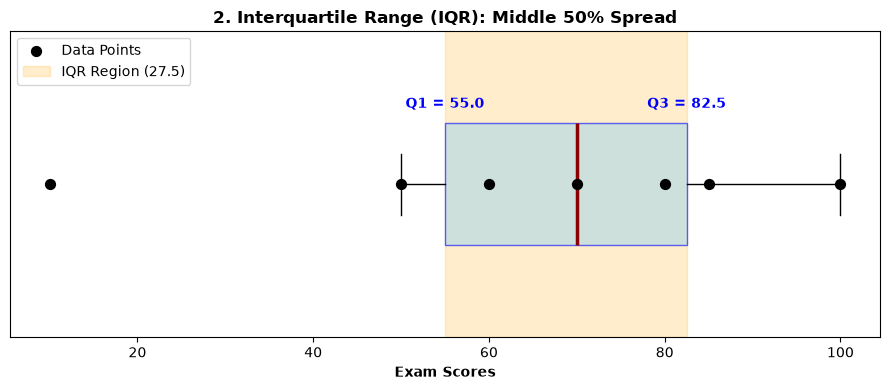

In [37]:
scores = [10, 50, 60, 70, 80, 85, 100]
q1 = np.percentile(scores, 25, method='linear')
q3 = np.percentile(scores, 75, method='linear')
iqr = q3 - q1

fig, ax = plt.subplots(figsize=(9, 4))

# Plot horizontal boxplot
bp = ax.boxplot(scores, orientation='horizontal', patch_artist=True, widths=0.4,
                boxprops=dict(facecolor='lightblue', color='blue', alpha=0.6),
                medianprops=dict(color='darkred', linewidth=2.5))

# Plot raw points
ax.scatter(scores, [1] * len(scores), color='black', zorder=4, label='Data Points', s=50)

# Highlight IQR span
ax.axvspan(q1, q3, color='orange', alpha=0.2, label=f'IQR Region ({iqr:.1f})')

# Annotate Q1 and Q3
ax.text(q1, 1.25, f'Q1 = {q1:.1f}', ha='center', color='blue', fontweight='bold')
ax.text(q3, 1.25, f'Q3 = {q3:.1f}', ha='center', color='blue', fontweight='bold')

ax.set_yticks([])
ax.set_xlabel('Exam Scores', fontweight='bold')
ax.set_title('2. Interquartile Range (IQR): Middle 50% Spread', fontweight='bold')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# 3. Sample Variance (Average square deviation)

In [38]:
# 3. Sample Variance Example
plants = [10, 20, 30]

# Plain Python
mean_val = sum(plants) / len(plants)
var_python = sum((x - mean_val) ** 2 for x in plants) / (len(plants) - 1)

# Standard Library (statistics)
var_stats = statistics.variance(plants)

# use numpy for variance
var_np = np.var(plants,ddof=1) # ddof =1 Bessel's correction

print(f"Plain Python calculation:  {var_python:.1f} cm²")
print(f"statistics.variance():      {var_stats:.1f} cm²")
print(f"np.var(ddof=1):            {var_np:.1f} cm²")

Plain Python calculation:  100.0 cm²
statistics.variance():      100.0 cm²
np.var(ddof=1):            100.0 cm²


# 4. Sample Standard Deviation(spread in original Units)

In [39]:
plants = [10, 20, 30]

# Plain Python
mean_val = sum(plants) / len(plants)
var_val = sum((x - mean_val) ** 2 for x in plants) / (len(plants) - 1)
std_python = math.sqrt(var_val)

# Standard Library (statistics)
std_stats = statistics.stdev(plants)

# NumPy Library (ddof=1 specifies sample standard deviation)
std_np = np.std(plants, ddof=1)

print(f"Plain Python calculation:  {std_python:.1f} cm")
print(f"statistics.stdev():        {std_stats:.1f} cm")
print(f"np.std(ddof=1):            {std_np:.1f} cm")

Plain Python calculation:  10.0 cm
statistics.stdev():        10.0 cm
np.std(ddof=1):            10.0 cm


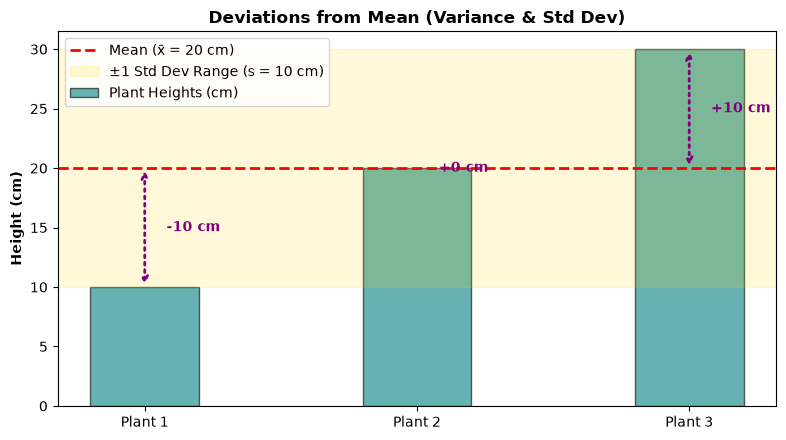

In [40]:
plants = [10, 20, 30]
mean_val = np.mean(plants)
std_val = np.std(plants, ddof=1)

fig, ax = plt.subplots(figsize=(8, 4.5))
x_indices = np.arange(1, len(plants) + 1)
bars = ax.bar(x_indices, plants, width=0.4, color='teal', alpha=0.6, label='Plant Heights (cm)', edgecolor='black')

# Draw Mean Line
ax.axhline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean (x̄ = {mean_val:.0f} cm)')

# Draw deviation vectors
for idx, h in zip(x_indices, plants):
    ax.annotate('', xy=(idx, h), xytext=(idx, mean_val),
                arrowprops=dict(arrowstyle='<->', color='purple', lw=2, linestyle=':'))
    dev = h - mean_val
    ax.text(idx + 0.08, (h + mean_val) / 2, f'{dev:+0.0f} cm', color='purple', fontweight='bold', va='center')


# Highlight ±1 Std Dev Band
ax.axhspan(mean_val - std_val, mean_val + std_val, color='gold', alpha=0.15, label=f'±1 Std Dev Range (s = {std_val:.0f} cm)')

ax.set_xticks(x_indices)
ax.set_xticklabels([f'Plant {i}' for i in x_indices])
ax.set_ylabel('Height (cm)', fontweight='bold')
ax.set_title('Deviations from Mean (Variance & Std Dev)', fontweight='bold')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Real-World Decision Examples
Use Sample Variance (
) when:
Manufacturing / QA: Testing 50 light bulbs out of a factory batch of 10,000 to check life expectancy variance.
Polling & Surveys: Surveying 1,000 voters to estimate the variation in voting preference across a country of 50 million.
Machine Learning / Data Science: Computing feature variance on a training set to generalize to unseen test/production data.
Medical Clinical Trials: Measuring blood pressure changes in 100 trial patients to infer variability for all future patients.
Use Population Variance (
) when:

In [41]:
# Dataset representing the ENTIRE population of 3 plant heights (in cm)
plants = [10, 20, 30]
N = len(plants)
mu = sum(plants) / N
# --- 1. POPULATION VARIANCE & STD DEV (ddof = 0) ---
# Plain Python
pop_var_py = sum((x - mu) ** 2 for x in plants) / N
pop_std_py = math.sqrt(pop_var_py)

# Standard Library
pop_var_stats = statistics.pvariance(plants)
pop_std_stats = statistics.pstdev(plants)

# NumPy (ddof=0 by default)
pop_var_np = np.var(plants, ddof=0)
pop_std_np = np.std(plants, ddof=0)

print("--- POPULATION (Entire Census) ---")
print(f"Population Variance (σ²): {pop_var_np:.2f} cm² (Python: {pop_var_py:.2f}, stats: {pop_var_stats:.2f})")
print(f"Population Std Dev  (σ):  {pop_std_np:.2f} cm  (Python: {pop_std_py:.2f}, stats: {pop_std_stats:.2f})")


# --- 2. SAMPLE VARIANCE & STD DEV (ddof = 1) ---
# Plain Python
sample_var_py = sum((x - mu) ** 2 for x in plants) / (N - 1)
sample_std_py = math.sqrt(sample_var_py)

# Standard Library
sample_var_stats = statistics.variance(plants)
sample_std_stats = statistics.stdev(plants)

# NumPy (requires explicit ddof=1)
sample_var_np = np.var(plants, ddof=1)
sample_std_np = np.std(plants, ddof=1)

print("\n--- SAMPLE (Subset / Estimation) ---")
print(f"Sample Variance (s²):     {sample_var_np:.2f} cm² (Python: {sample_var_py:.2f}, stats: {sample_var_stats:.2f})")
print(f"Sample Std Dev  (s):      {sample_std_np:.2f} cm  (Python: {sample_std_py:.2f}, stats: {sample_std_stats:.2f})")



--- POPULATION (Entire Census) ---
Population Variance (σ²): 66.67 cm² (Python: 66.67, stats: 66.67)
Population Std Dev  (σ):  8.16 cm  (Python: 8.16, stats: 8.16)

--- SAMPLE (Subset / Estimation) ---
Sample Variance (s²):     100.00 cm² (Python: 100.00, stats: 100.00)
Sample Std Dev  (s):      10.00 cm  (Python: 10.00, stats: 10.00)


# 5. Mean Absolute Deviation (MAD)

Plain Python calculation: 6.67 minutes
NumPy vector operations:   6.67 minutes


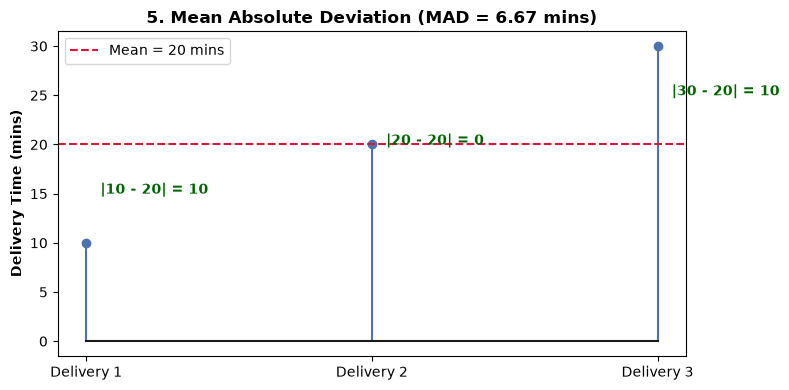

In [42]:
# 5. Mean Absolute Deviation Example
deliveries = [10, 20, 30]
# Plain Python
mean_val = sum(deliveries) / len(deliveries)
mad_python = sum(abs(x - mean_val) for x in deliveries) / len(deliveries)

# NumPy Library
mad_np = np.mean(np.abs(np.array(deliveries) - np.mean(deliveries)))

print(f"Plain Python calculation: {mad_python:.2f} minutes")
print(f"NumPy vector operations:   {mad_np:.2f} minutes")


mean_val = np.mean(deliveries)
mad_val = np.mean(np.abs(np.array(deliveries) - mean_val))
fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(len(deliveries))
ax.stem(x, deliveries, linefmt='b-', markerfmt='bo', basefmt='k-')

# Mean line
ax.axhline(mean_val, color='crimson', linestyle='--', label=f'Mean = {mean_val:.0f} mins')

# Annotate absolute distances
for i, d in enumerate(deliveries):
    abs_dev = abs(d - mean_val)
    ax.text(i + 0.05, (d + mean_val) / 2, f'|{d} - {mean_val:.0f}| = {abs_dev:.0f}', 
            color='darkgreen', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f'Delivery {i+1}' for i in x])
ax.set_ylabel('Delivery Time (mins)', fontweight='bold')
ax.set_title(f'5. Mean Absolute Deviation (MAD = {mad_val:.2f} mins)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# 6. Median Absolute Deviation (Median MAD)

In [43]:
# 6. Median Absolute Deviation Example
wages = [10, 12, 15, 20, 100]

# Plain Python
med_val = statistics.median(wages)
devs = [abs(x - med_val) for x in wages]
mad_med_python = statistics.median(devs)

# NumPy Library
mad_med_np = np.median(np.abs(np.array(wages) - np.median(wages)))

# SciPy Library
mad_med_scipy = stats.median_abs_deviation(wages, scale=1)

print(f"Plain Python calculation: ${mad_med_python:.2f}")
print(f"NumPy calculation:        ${mad_med_np:.2f}")
print(f"scipy.stats.median_abs_deviation(): ${mad_med_scipy:.2f}")

Plain Python calculation: $5.00
NumPy calculation:        $5.00
scipy.stats.median_abs_deviation(): $5.00


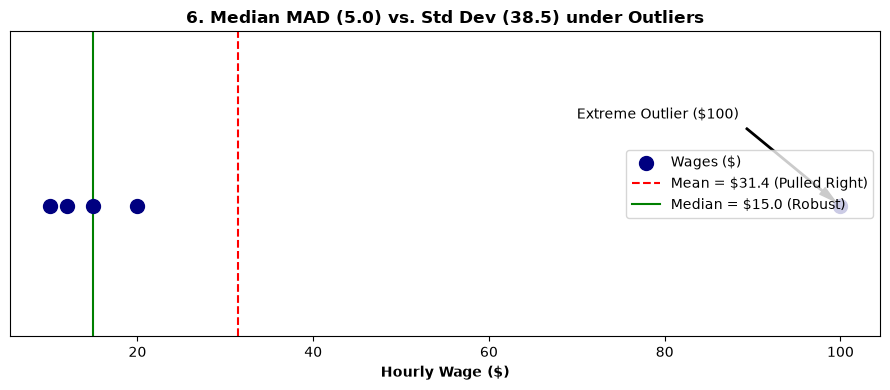

In [44]:
# 6. Median Absolute Deviation Visualization (With Outliers)
wages = [10, 12, 15, 20, 100]
med_val = np.median(wages)
mean_val = np.mean(wages)
std_val = np.std(wages, ddof=1)
mad_med = stats.median_abs_deviation(wages, scale=1)

fig, ax = plt.subplots(figsize=(9, 4))

ax.scatter(wages, [1] * len(wages), color='navy', s=100, zorder=3, label='Wages ($)')

# Annotate Outlier
ax.annotate('Extreme Outlier ($100)', xy=(100, 1), xytext=(70, 1.2),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

# Lines for Mean vs Median
ax.axvline(mean_val, color='red', linestyle='--', label=f'Mean = ${mean_val:.1f} (Pulled Right)')
ax.axvline(med_val, color='green', linestyle='-', label=f'Median = ${med_val:.1f} (Robust)')

ax.set_ylim(0.7, 1.4)
ax.set_yticks([])
ax.set_xlabel('Hourly Wage ($)', fontweight='bold')
ax.set_title(f'6. Median MAD ({mad_med:.1f}) vs. Std Dev ({std_val:.1f}) under Outliers', fontweight='bold')
ax.legend(loc='center right')
plt.tight_layout()
plt.show()

# 7. Coefficient of Variation (Relative Variability)

In [45]:
# 7. Coefficient of Variation Example
prices = [10, 12, 15, 18, 20]
# Plain Python
mean_val = sum(prices) / len(prices)
std_val = statistics.stdev(prices)
cv_python = (std_val / mean_val) * 100

# SciPy Library (stats.variation returns proportion; multiply by 100 for %)
cv_scipy_1 = stats.variation(prices) * 100 # uses population standard deviation(N) (ddof=0) by default
cv_scipy_2 = stats.variation(prices,ddof=1) * 100 # uses sample standard deviation(N-1) (ddof=1)

print(f"Plain Python calculation: {cv_python:.2f}%")
print(f"scipy.stats.variation() (population, ddof=0):  {cv_scipy_1:.2f}%")
print(f"scipy.stats.variation() (sample, ddof=1):      {cv_scipy_2:.2f}%")

Plain Python calculation: 27.49%
scipy.stats.variation() (population, ddof=0):  24.59%
scipy.stats.variation() (sample, ddof=1):      27.49%


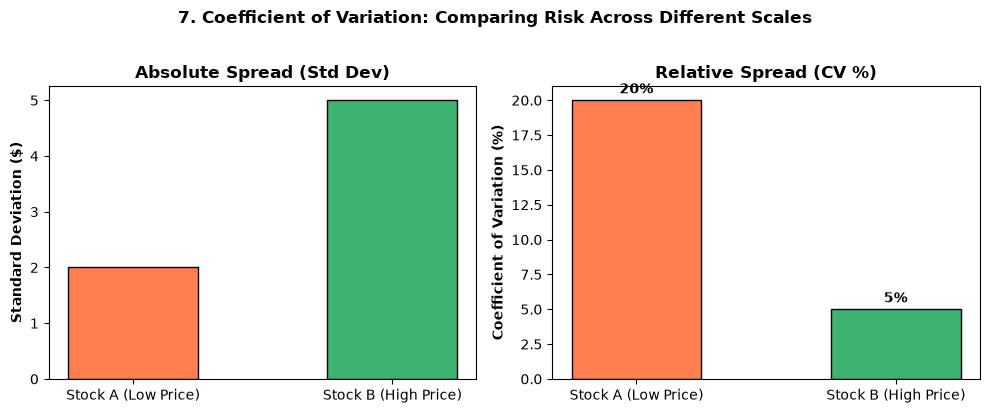

In [46]:
means = [10, 100]
stds = [2, 5]
cvs = [(s / m) * 100 for m, s in zip(means, stds)]
labels = ['Stock A (Low Price)', 'Stock B (High Price)']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Chart 1: Absolute Standard Deviation
ax1.bar(labels, stds, color=['coral', 'mediumseagreen'], edgecolor='black', width=0.5)
ax1.set_ylabel('Standard Deviation ($)', fontweight='bold')
ax1.set_title('Absolute Spread (Std Dev)', fontweight='bold')

# Chart 2: Relative Variation (CV %)
bars2 = ax2.bar(labels, cvs, color=['coral', 'mediumseagreen'], edgecolor='black', width=0.5)
ax2.set_ylabel('Coefficient of Variation (%)', fontweight='bold')
ax2.set_title('Relative Spread (CV %)', fontweight='bold')

for bar, cv in zip(bars2, cvs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{cv:.0f}%', 
             ha='center', fontweight='bold')

plt.suptitle('7. Coefficient of Variation: Comparing Risk Across Different Scales', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 4: Measures of Shape & Distribution Geometry
While central tendency measures the middle, dispersion measures the spread, and position measures relative rank, measures of shape describe the structural geometry, asymmetry, and tail thickness of a distribution.

Below are clear, naive examples covering the core measures of distribution shape, complete with mathematical formulas, notation pronunciations, and Python implementation comparisons across Plain Python, Standard Library statistics, and NumPy / SciPy.

# 1. Skewness (Asymmetry of Distribution)


Plain Python (Population Skewness): +1.487
SciPy stats.skew (bias=True):       +1.487
SciPy stats.skew (bias=False):      +2.217


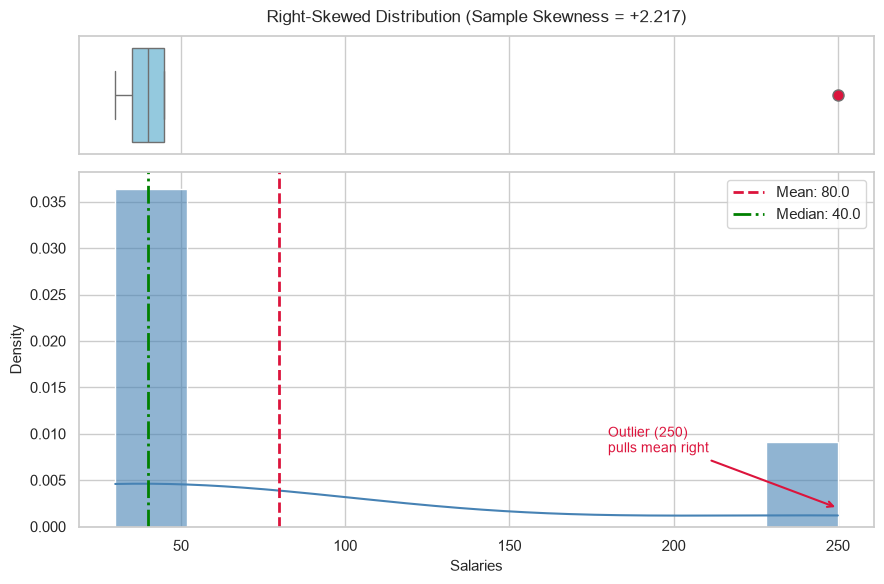

In [47]:
salaries = [30, 35, 40, 45, 250]
n = len(salaries)

# Plain Python
median_val = np.median(salaries)
mean_val = sum(salaries) / n
var_val = sum((x - mean_val) ** 2 for x in salaries) / n
std_val = math.sqrt(var_val)
m3 = sum((x - mean_val) ** 3 for x in salaries) / n
skew_python = m3 / (std_val ** 3)

# SciPy Library
# bias=True calculates population skewness; bias=False applies sample correction
skew_scipy_pop = stats.skew(salaries, bias=True)
skew_scipy_sample = stats.skew(salaries, bias=False)

# + indicates right skew, - indicates left skew

print(f"Plain Python (Population Skewness): {skew_python:+.3f}")  # +ve indicates right skew, -ve indicates left skew
print(f"SciPy stats.skew (bias=True):       {skew_scipy_pop:+.3f}")  # +ve indicates right skew, -ve indicates left skew
print(f"SciPy stats.skew (bias=False):      {skew_scipy_sample:+.3f}")  # +ve indicates right skew, -ve indicates left skew


# 2. Visualization Setup
sns.set_theme(style="whitegrid")
fig, (ax_box, ax_hist) = plt.subplots(
    2,
    1,
    figsize=(9, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [0.25, 0.75]},
)

# Top Plot: Boxplot (Highlights the extreme outlier at 250)
sns.boxplot(x=salaries, ax=ax_box, color="skyblue", flierprops={"markerfacecolor": "crimson", "markersize": 8})
ax_box.set(xlabel="")
ax_box.set_title(
    f"Right-Skewed Distribution (Sample Skewness = {skew_scipy_sample:+.3f})",
    fontsize=12,
    pad=10,
)

# Bottom Plot: Histogram + Kernel Density Estimate (KDE)
sns.histplot(salaries, kde=True, ax=ax_hist, color="steelblue", bins=10, stat="density", alpha=0.6)

# Annotate Mean vs Median to show the effect of the outlier on skewness
ax_hist.axvline(mean_val, color="crimson", linestyle="--", linewidth=2, label=f"Mean: {mean_val:.1f}")
ax_hist.axvline(median_val, color="green", linestyle="-.", linewidth=2, label=f"Median: {median_val:.1f}")

# Annotate Outlier Point
ax_hist.annotate(
    "Outlier (250)\npulls mean right",
    xy=(250, 0.002),
    xytext=(180, 0.008),
    arrowprops=dict(arrowstyle="->", color="crimson", lw=1.5),
    fontsize=10,
    color="crimson",
)

ax_hist.set_xlabel("Salaries", fontsize=11)
ax_hist.set_ylabel("Density", fontsize=11)
ax_hist.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

# 2. Kurtosis & Excess Kurtosis (Tail Thickness & Extremity)

Plain Python (Excess Kurtosis):    -0.491
SciPy Excess Kurtosis (fisher=True): -0.491
SciPy Raw Kurtosis (fisher=False):   +2.509


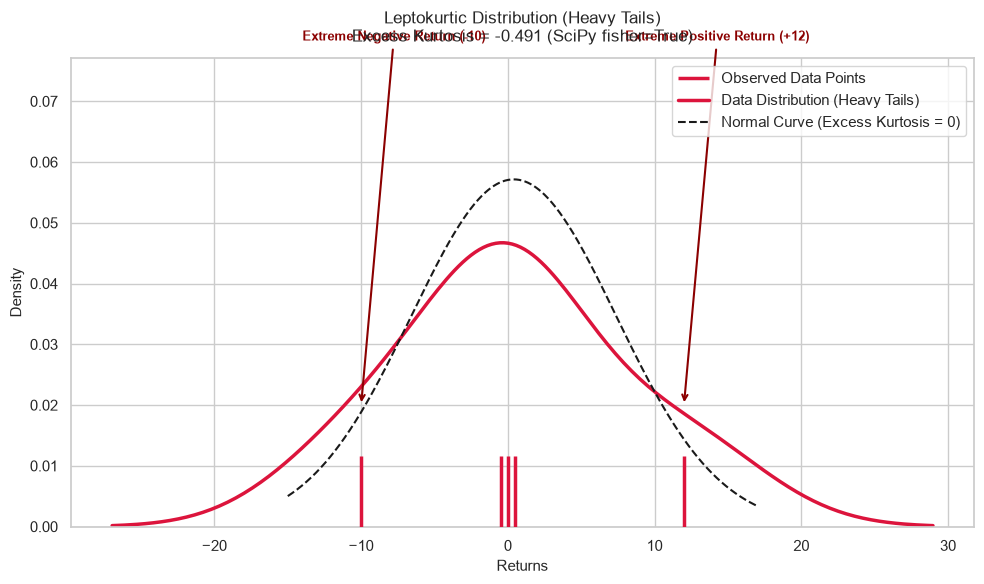

In [48]:
returns = [-10, -0.5, 0, 0.5, 12]
n = len(returns)

# Plain Python
mean_val = sum(returns) / n
var_val = sum((x - mean_val) ** 2 for x in returns) / n
std_val = math.sqrt(var_val)
m4 = sum((x - mean_val) ** 4 for x in returns) / n
kurtosis_raw = m4 / (std_val ** 4)
excess_kurtosis_python = kurtosis_raw - 3.0

# SciPy Library (fisher=True calculates Excess Kurtosis relative to 3.0)
excess_kurt_scipy = stats.kurtosis(returns, fisher=True, bias=True)
raw_kurt_scipy = stats.kurtosis(returns, fisher=False, bias=True)

print(f"Plain Python (Excess Kurtosis):    {excess_kurtosis_python:+.3f}")
print(f"SciPy Excess Kurtosis (fisher=True): {excess_kurt_scipy:+.3f}")
print(f"SciPy Raw Kurtosis (fisher=False):   {raw_kurt_scipy:+.3f}")


# 2. Visualization Setup
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# Plot actual data points as vertical markers (rug plot) and kernel density
# rugplot : Displays individual data points along the x-axis as small vertical lines, providing a visual representation of the distribution of the data.
sns.rugplot(returns, ax=ax, color="crimson", height=0.15, linewidth=2.5, label="Observed Data Points", zorder=5)
sns.kdeplot(returns, ax=ax, color="crimson", linewidth=2.5, label="Data Distribution (Heavy Tails)")
# kde : Kernel Density Estimate provides a smooth estimate of the probability density function of the returns.

# Overlay a reference Normal Distribution with same mean & std for comparison
x_range = np.linspace(min(returns) - 5, max(returns) + 5, 500)
norm_pdf = stats.norm.pdf(x_range, loc=mean_val, scale=std_val)
ax.plot(x_range, norm_pdf, "k--", linewidth=1.5, label=f"Normal Curve (Excess Kurtosis = 0)")

# Annotate Extreme Tail Outliers contributing to high m4
ax.annotate(
    "Extreme Negative Return (-10)",
    xy=(-10, 0.02),
    xytext=(-14, 0.08),
    arrowprops=dict(arrowstyle="->", color="darkred", lw=1.5),
    fontsize=9.5,
    color="darkred",
    fontweight="bold",
)

ax.annotate(
    "Extreme Positive Return (+12)",
    xy=(12, 0.02),
    xytext=(8, 0.08),
    arrowprops=dict(arrowstyle="->", color="darkred", lw=1.5),
    fontsize=9.5,
    color="darkred",
    fontweight="bold",
)

# Plot Details
ax.set_title(
    f"Leptokurtic Distribution (Heavy Tails)\nExcess Kurtosis = {excess_kurt_scipy:+.3f} (SciPy fisher=True)",
    fontsize=12,
    pad=12,
)
ax.set_xlabel("Returns", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

# 3. Pearson's Median Skewness Coefficient (Robust Non-Parametric Skew)

Mean:   6.40 mins
Median: 3.00 mins
Pearson's Skewness (Python): +1.336
Pearson's Skewness (NumPy):  +1.336


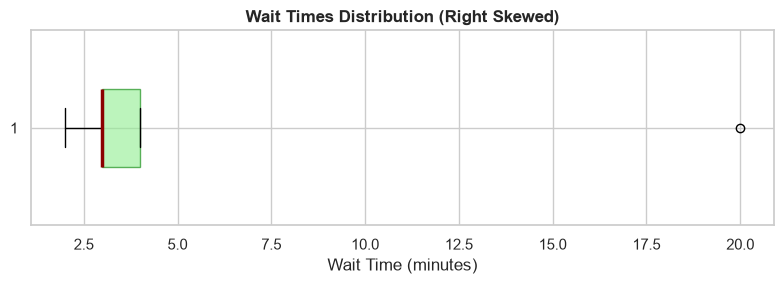

In [49]:
wait_times = [2, 3, 3, 4, 20]

# Plain Python / Standard Library
mean_val = statistics.mean(wait_times)
median_val = statistics.median(wait_times)
std_val = statistics.stdev(wait_times)
pearsons_skew_py = (3 * (mean_val - median_val)) / std_val

# NumPy Vector Operations
np_data = np.array(wait_times)
pearsons_skew_np = (3 * (np.mean(np_data) - np.median(np_data))) / np.std(np_data, ddof=1)

print(f"Mean:   {mean_val:.2f} mins")
print(f"Median: {median_val:.2f} mins")
print(f"Pearson's Skewness (Python): {pearsons_skew_py:+.3f}")
print(f"Pearson's Skewness (NumPy):  {pearsons_skew_np:+.3f}")

# Horizontal Boxplot Visualization using orientation parameter
fig, ax = plt.subplots(figsize=(8, 3))
bp = ax.boxplot(wait_times, orientation='horizontal', patch_artist=True, widths=0.4,
                boxprops=dict(facecolor='lightgreen', color='green', alpha=0.6),
                medianprops=dict(color='darkred', linewidth=2.5))
ax.set_title("Wait Times Distribution (Right Skewed)", fontweight='bold')
ax.set_xlabel("Wait Time (minutes)")
plt.tight_layout()
plt.show()

# Pearson's Median Skewness
Pearson's Median Skewness measures the asymmetry of a distribution based on the distance between the mean and median:



# Section 3: Measures of Position (Relative Standing)

While central tendency gives the middle and dispersion measures the spread, measures of position describe where a specific data point or value stands relative to the rest of the distribution.

Below are clear, naive examples covering the core measures of position, complete with mathematical formulas, notation pronunciations, and Python implementation comparisons across Plain Python, Standard Library statistics, and NumPy / SciPy / Matplotlib.

# 1. Percentiles (Division into 100 Equal Parts)

In [50]:
# 1. Percentile Example (80th Percentile)
scores = [40, 50, 60, 70, 80, 85, 90, 95, 98, 100]
p = 80

# Plain Python (Nearest-rank / Interpolation method)
sorted_scores = sorted(scores)
idx = int(np.ceil((p / 100) * len(sorted_scores))) - 1
p80_python = sorted_scores[idx]

# Standard Library (statistics.quantiles - divides into 100 intervals)
# Note: quantiles returns 99 cut points for percentiles
p80_stats = statistics.quantiles(scores, n=100)[79]

# NumPy Library (np.percentile)
p80_np = np.percentile(scores, p)

# SciPy Library (stats.scoreatpercentile)
p80_scipy = stats.scoreatpercentile(scores, p)

print(f"Plain Python (Nearest Rank):  {p80_python}")
print(f"statistics.quantiles(n=100): {p80_stats:.2f}")
print(f"np.percentile():             {p80_np:.2f}")
print(f"scipy scoreatpercentile():   {p80_scipy:.2f}")

Plain Python (Nearest Rank):  95
statistics.quantiles(n=100): 97.40
np.percentile():             95.60
scipy scoreatpercentile():   95.60


# 2. Quartiles & Interquartile Range (Division into 4 Equal Parts)

--- Standard Library (statistics.quantiles) ---
Q1: 4.0, Q2 (Median): 8.0, Q3: 12.0

--- NumPy Library (np.percentile) ---
Q1: 5.0, Q2 (Median): 8.0, Q3: 11.0


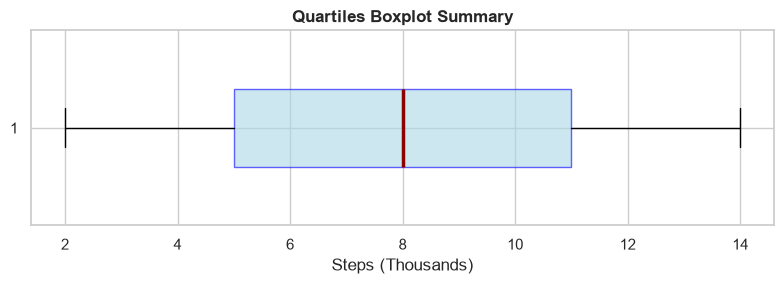

In [51]:
# 2. Quartiles Example
steps = [2, 4, 6, 8, 10, 12, 14]
# Standard Library (statistics.quantiles - splits into 4 parts: Q1, Q2, Q3)
q1_stats, q2_stats, q3_stats = statistics.quantiles(steps, n=4)
# NumPy Library
q1_np, q2_np, q3_np = np.percentile(steps, [25, 50, 75])

print("--- Standard Library (statistics.quantiles) ---")
print(f"Q1: {q1_stats:.1f}, Q2 (Median): {q2_stats:.1f}, Q3: {q3_stats:.1f}")

print("\n--- NumPy Library (np.percentile) ---")
print(f"Q1: {q1_np:.1f}, Q2 (Median): {q2_np:.1f}, Q3: {q3_np:.1f}")
# Visualization using horizontal Boxplot (using non-deprecated orientation parameter)
fig, ax = plt.subplots(figsize=(8, 3))
bp = ax.boxplot(steps, orientation='horizontal', patch_artist=True, widths=0.4,
                boxprops=dict(facecolor='lightblue', color='blue', alpha=0.6),
                medianprops=dict(color='darkred', linewidth=2.5))
ax.set_title("Quartiles Boxplot Summary", fontweight='bold')
ax.set_xlabel("Steps (Thousands)")
plt.tight_layout()
plt.show()

# 3. Z-Score / Standard Score (Distance from Mean in Std Devs)

In [52]:
# 3. Z-Score Example
data = [50, 60, 70, 80, 90]
target_val = 85

# Plain Python
mean_val = sum(data) / len(data)
std_val = math.sqrt(sum((x - mean_val) ** 2 for x in data) / (len(data) - 1))
z_python = (target_val - mean_val) / std_val

# SciPy Library (Calculates Z-scores for all elements in array)
# ddof=1 ensures sample standard deviation in denominator
z_array_scipy = stats.zscore(data + [target_val], ddof=1)
z_target_scipy = z_array_scipy[-1]

# NumPy Vectorized Transformation for Entire Dataset
np_data = np.array(data)
z_all_np = (np_data - np.mean(np_data)) / np.std(np_data, ddof=1)

print(f"Plain Python Z-Score for x=85:       {z_python:+.3f}")
print(f"SciPy stats.zscore for x=85:         {z_target_scipy:+.3f}")
print(f"NumPy Z-scores for full dataset:   {np.round(z_all_np, 2)}")

Plain Python Z-Score for x=85:       +0.949
SciPy stats.zscore for x=85:         +0.811
NumPy Z-scores for full dataset:   [-1.26 -0.63  0.    0.63  1.26]


# 4. Percentile Rank (Percentage of Scores At or Below a Value)

In [53]:
# 4. Percentile Rank Example
scores = [50, 60, 70, 70, 80, 90]
target_score = 70

# Plain Python
count_less = sum(1 for x in scores if x < target_score)
count_equal = sum(1 for x in scores if x == target_score)
pr_python = ((count_less + 0.5 * count_equal) / len(scores)) * 100

# SciPy Library (stats.percentileofscore)
# kind='weak' counts <= target, kind='rank' uses fractional ranking
pr_scipy_strict = stats.percentileofscore(scores, target_score, kind='strict') # strict counts < target
pr_scipy_mean = stats.percentileofscore(scores, target_score, kind='mean')

print(f"Plain Python Percentile Rank (x=70): {pr_python:.1f}%")
print(f"SciPy percentileofscore (kind='mean'): {pr_scipy_mean:.1f}%")
print(f"SciPy percentileofscore (kind='strict'): {pr_scipy_strict:.1f}%")

Plain Python Percentile Rank (x=70): 50.0%
SciPy percentileofscore (kind='mean'): 50.0%
SciPy percentileofscore (kind='strict'): 33.3%
